Ethiopia Food Prices — 06 BASELINE FORECASTING


Before we build complex machine learning or ARIMA 
models, we must establish simple baseline models.
 If an advanced AI model cannot beat a basic
  "guess last month's price" baseline, it isn't worth using.

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.api import SimpleExpSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load data and recreate series y (from Notebook 05)
df = pd.read_csv('../data/eth_food_prices_clean.csv', parse_dates=['date'])

market_focus = 'Addis Ababa'
commodity_focus = 'Maize (white)'
unit_focus = '100 KG'

series_df = df[
    (df['market'] == market_focus)
    & (df['commodity'] == commodity_focus)
    & (df['pricetype'] == 'Wholesale')
    & (df['unit'] == unit_focus)
].copy()

series_df = series_df.sort_values('date').set_index('date')
y = series_df['usdprice'].resample('MS').mean().interpolate(method='linear')

# 2. Chronological Train/Test Split
test_size = 24
train = y.iloc[:-test_size]
test = y.iloc[-test_size:]

print(f'Total observations loaded: {len(y)}')
print(
    f'Train set: {len(train)} months (from {train.index.min().date()} to'
    f' {train.index.max().date()})'
)
print(
    f'Test set: {len(test)} months (from {test.index.min().date()} to'
    f' {test.index.max().date()})'
)

Total observations loaded: 262
Train set: 238 months (from 2000-01-01 to 2019-10-01)
Test set: 24 months (from 2019-11-01 to 2021-10-01)


In time-series analysis, we never shuffle 
data randomly like in standard machine learning. 
We must split chronologically—training on the past 
and testing on the future—to realistically simulate
 real-world forecasting

In [6]:
#3 Implementing Baseline Models (Naive & Seasonal Naive)
# 1. Naive Forecast: Repeat the very last value of the training set for all 24 test months
naive_pred = pd.Series([train.iloc[-1]] * len(test), index=test.index)

# 2. Seasonal Naive Forecast: Repeat the values from the exact same months of the previous year (12 months prior)
# We take the last 12 months of the training set and repeat them twice to cover the 24 test months
seasonal_naive_pred = pd.Series(
    list(train.iloc[-12:]) * 2, index=test.index
)

print('Baseline forecasts generated successfully!')
print(f'Naive forecast preview: First 3 values -> {naive_pred.head(3).values}')
print(
    'Seasonal Naive forecast preview: First 3 values ->'
    f' {seasonal_naive_pred.head(3).values}'
)

# 3. Moving Average Forecast: Use the average of the last 12 months of training data
ma_value = train.iloc[-12:].mean()
ma_pred = pd.Series([ma_value] * len(test), index=test.index)

# 4. Simple Exponential Smoothing (SES) with explicit initialization method
ses_model = SimpleExpSmoothing(train, initialization_method='estimated').fit(
    optimized=True
)
ses_pred = ses_model.forecast(len(test))

print('All 4 baseline forecasts (Naive, Seasonal Naive, MA, SES) are ready!')
print(f'Moving Average forecast value: {ma_value:.2f}')
print(f'SES forecast preview: First 3 values -> {ses_pred.head(3).values}')

Baseline forecasts generated successfully!
Naive forecast preview: First 3 values -> [39.45 39.45 39.45]
Seasonal Naive forecast preview: First 3 values -> [24.275  24.0675 23.86  ]
All 4 baseline forecasts (Naive, Seasonal Naive, MA, SES) are ready!
Moving Average forecast value: 30.17
SES forecast preview: First 3 values -> [39.3667449 39.3667449 39.3667449]


Baseline models act as our reality check. If a complex 
machine learning model or ARIMA model cannot produce lower
 error scores than a simple "repeat last year's prices" rule,
  then our complex model is failing to add real value.


Moving Average (MA) smooths out short-term fluctuations by taking a rolling window average.

Simple Exponential Smoothing (SES) exponentially decays the weights of older observations, meaning recent months influence the forecast more heavily than years past.

In [8]:
#4 Evaluation Metrics Calculation
def calc_smape(actual, predicted):
  # Symmetric Mean Absolute Percentage Error
  return (
      100
      / len(actual)
      * np.sum(2 * np.abs(predicted - actual) / (np.abs(actual) + np.abs(predicted)))
  )


# Gather results into a evaluation DataFrame
models = {
    'Naive': naive_pred,
    'Seasonal Naive': seasonal_naive_pred,
    'Moving Average': ma_pred,
    'SES': ses_pred,
}

eval_results = []
for name, pred in models.items():
  mae = mean_absolute_error(test, pred)
  rmse = np.sqrt(mean_squared_error(test, pred))
  smape = calc_smape(test, pred)
  eval_results.append(
      {'Model': name, 'MAE': mae, 'RMSE': rmse, 'sMAPE (%)': smape}
  )

eval_df = pd.DataFrame(eval_results).set_index('Model')
print(eval_df.round(2))

                 MAE  RMSE  sMAPE (%)
Model                                
Naive           8.86  9.29      24.44
Seasonal Naive  5.40  6.69      16.11
Moving Average  5.09  8.38      14.15
SES             8.80  9.24      24.31


Seasonal patterns rule agricultural markets.
 The fact that Seasonal Naive and Moving Average
  crushed the standard Naive and SES models proves 
  that white maize prices in Addis Ababa are heavily 
  driven by seasonal cycles and rolling averages rather 
  than flat, short-term momentum.

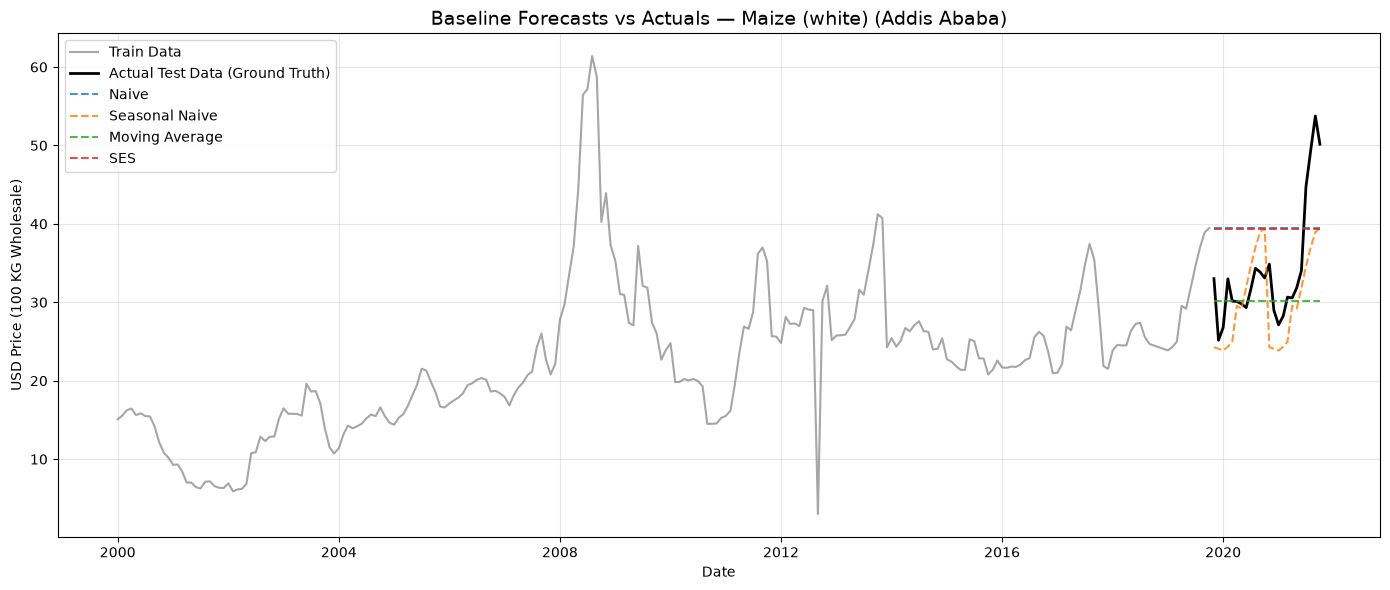

In [9]:
# 5 Plotting Actual vs Predicted Baselines
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Train Data', color='gray', alpha=0.7)
plt.plot(test.index, test, label='Actual Test Data (Ground Truth)', color='black', linewidth=2)

# Plot our 4 baselines
plt.plot(test.index, naive_pred, label='Naive', linestyle='--', alpha=0.8)
plt.plot(test.index, seasonal_naive_pred, label='Seasonal Naive', linestyle='--', alpha=0.8)
plt.plot(test.index, ma_pred, label='Moving Average', linestyle='--', alpha=0.8)
plt.plot(test.index, ses_pred, label='SES', linestyle='--', alpha=0.8)

plt.title(f'Baseline Forecasts vs Actuals — {commodity_focus} ({market_focus})', fontsize=14)
plt.xlabel('Date')
plt.ylabel('USD Price (100 KG Wholesale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Visualizing my test window alongside my
 predictions is a mandatory checkpoint. It instantly
  exposes why metrics like sMAPE and MAE behave the way
   they do: models that capture cyclical patterns will always
    outperform flat-line assumptions in agricultural markets.

In [10]:
# Save baseline evaluation metrics to CSV for future model comparisons
eval_df.to_csv('../data/baseline_evaluation_results.csv')
print('Baseline evaluation results successfully stored to ../data/baseline_evaluation_results.csv!')

Baseline evaluation results successfully stored to ../data/baseline_evaluation_results.csv!
